## Projet COMPLEX Couverture de Graphe
 Emirha Faruk  
 Théo-Paul Ladet

##### Fonctions utilitaires:

In [67]:

from pathlib import Path
from typing import Any, Callable, List, Optional, Tuple


def readFile(filename: str) -> List[str]:
    p = Path("graphs") / filename
    try:
        with p.open("r", encoding="utf-8") as f:
            return f.readlines()
    except FileNotFoundError:
        print("Erreur pendant lecture de fichier: file not found", p)
        raise
    except Exception as e:
        # Re-raise as FileNotFoundError for compatibility with existing callers
        print(f"Erreur pendant lecture de fichier: {e}")
        raise FileNotFoundError from e

def extractProps(lines):
    nbsommets = 0
    sommets = []
    nbaretes = 0
    aretes = []
    status = 0 
    """
    1 -> nb sommets
    2 -> sommets
    3 -> nb aretes
    4 -> aretes
    """
    for line in lines:
        line = line.strip()
        if (line == "" or line[0] in [i for i in range(10)]) and status == 0:
            continue
        if line[0] in [str(i) for i in range(10)]:
            if status == 1:
                try:
                    nbsommets = int(line)
                except:
                    print(f"Erreur pendant lecture de nb sommet {line}")
                    raise ValueError
                status = 0
            elif status == 2:
                try:
                    sommets.append(line) # Change ici pour avoir string a la place d'entier
                except:
                    print(f"Erreur pendant lecture de sommet {line}")
                    raise ValueError
            elif status == 3:
                try:
                    nbaretes = int(line)
                except:
                    print(f"Erreur pendant lecture de nb arete {line}")
                    raise ValueError
                status = 0
            elif status == 4:
                try:
                    narete = line.split(" ") 
                    if len(narete) != 2:
                        raise ValueError
                    aretes.append(narete)
                except:
                    print(f"Erreur pendant lecture de arete {line}")
                    raise ValueError
        else:
            if line == "Nombre de sommets":
                status = 1
            elif line == "Sommets":
                status = 2
            elif line == "Nombre d aretes":
                status = 3
            elif line == "Aretes":
                status = 4
        
    return nbsommets, sommets[:nbsommets], nbaretes, aretes[:nbaretes]


def reformatProps(props):
    sommets = dict()
    for sommet in props[1]:
        sommets[sommet] = ""
    for arete in props[3]:
        sommets[arete[0]] = sommets[arete[0]] + " " + arete[1]
        sommets[arete[0]] = sommets[arete[0]].strip()
    return [(sommet + " " + aretes).strip() for sommet, aretes in sommets.items()]


def test(filename):
    lines = readFile("exemple.txt")
    props = extractProps(lines)
    reprops = reformatProps(props)
    print(reprops)



In [68]:
import networkx as nx
import random
import matplotlib.pyplot as plt
import os
from pathlib import Path

def parseTxt(filename):
    try:
        file_path = os.path.join(os.path.dirname(os.path.abspath(__file__)), filename)
        lines = readFile(file_path)
        props = extractProps(lines)
        reprops = reformatProps(props)
        G = nx.parse_adjlist(reprops, nodetype=int)
    except:
        print("failure with first parse, using alt")
        G = parseTxt_alt(filename)
    return G



def parseTxt_alt(filename, base_dir=None, encoding="utf-8"):
    if base_dir is None:
        try:
            base_dir = Path(__file__).parent  
        except NameError:
            base_dir = Path.cwd()          

    file_path = (base_dir / filename).resolve()
    with open(file_path, "r", encoding=encoding) as f:
                lines = [line.strip() for line in f if line.strip()]
    edges = [tuple(map(int, line.split())) for line in lines[lines.index("Aretes") + 1:]]
    G = nx.Graph()
    G.add_edges_from(edges)
    return G

def print_graph(G):
    print("Nodes:", G.nodes())
    print("Edges:", G.edges())    

def plot_graph(G, title=None):
    fig = plt.figure()
    nx.draw(G, with_labels=True)
    if title:
        try:
            fig.canvas.manager.set_window_title(title)
        except Exception:
            fig.suptitle(title)
    plt.show(block=False)



In [69]:
def makePlotForMoyennesNFixed(algomoyennes):
    algoname = algomoyennes[0]
    moyennesetsommets = algomoyennes[1:]
    probas = [x[0] for x in moyennesetsommets]
    moyennes = [x[1] for x in moyennesetsommets]
    print(algoname)
    print(probas)
    print(moyennes)
    plt.plot(probas, moyennes)
    plt.xlabel("Probabilité")
    plt.ylabel("Temps")
    
    plt.title(algoname)
    plt.show()


def makePlotForMoyennes(algomoyennes):
    algoname = algomoyennes[0]
    moyennesetsommets = algomoyennes[1:]
    nbsommets = [x[0] for x in moyennesetsommets]
    moyennes = [x[1] for x in moyennesetsommets]
    print(algoname)
    print(nbsommets)
    print(moyennes)
    plt.plot(nbsommets, moyennes)
    plt.xlabel("Nombre de sommets")
    plt.ylabel("Temps")
    
    plt.title(algoname)
    plt.show()

In [70]:
# TODO: MAKE FUNCS HERE TO SAVE THE GRAPHS AND RESULTS
from pathlib import Path
from typing import Any


def toStringGraph(graph: Any) -> str:
    nodes = list(graph.nodes())
    edges = list(graph.edges())
    res = "Nombre de sommets\n"
    res += f"{len(nodes)}\n"
    res += "Sommets\n"
    for node in nodes:
        res += f"{node}\n"
    res += "Nombre d aretes\n"
    res += f"{len(edges)}\n"
    res += "Aretes\n"
    for edge in edges:
        res += f"{edge[0]} {edge[1]}\n"
    return res


def saveGraphToFile(graph: Any, filename: str) -> None:
    out_dir = Path("graphs")
    out_dir.mkdir(parents=True, exist_ok=True)
    p = out_dir / filename
    # Use Path.open for better portability
    with p.open("w", encoding="utf-8") as f:
        f.write(toStringGraph(graph))
    print(f"Graph saved to {p}")

In [71]:
import time


def get_time():
    return time.time()

def get_calctime(t):
    return time.time() - t

#### 2 Graphes
2.1 Operations de base
 1. Coder une methode prenant en parametres un graphe G et un sommet v de G, et qui retourne
 un nouveau graphe Gobtenu a partir de G en supprimant le sommet v (et les aretes incidentes).
 Precision : la methode doit fonctionner meme si les n sommets du graphe ne sont pas les entiers
 de 0 a n 1(par exemple on peut vouloir supprimer le sommet 3 dun graphe avec 4 sommets
 0368 ).


In [72]:
def remove_node_copy(G, n):
    H = G.copy()
    H.remove_node(n)
    return H

 2. Generaliser la methode precedente lorsquun ensemble de sommets est supprime

In [73]:
def remove_node_list_copy(G, l):
    H = G.copy()
    for n in l :
        H.remove_node(n)
    return H


3. Coder une methode prenant en entree un graphe et renvoyant un tableau contenant les degres
 des sommets du graphe, et une autre permettant de determiner un sommet de degre maximum.
 Ici aussi, la methode doit fonctionner meme si les n sommets du graphe ne sont pas les entiers
 de 0 a n 1.

In [74]:
def degree_map(G) :
    return dict(G.degree())

def max_degree_vertex(G):
    degs = degree_map(G)
    if not degs:
        raise ValueError("max_degree_vertex: graph has no nodes")
    return max(degs, key=degs.get)

 2.2 Generation dinstances
 - Afin de tester vos algorithmes, vous allez generer des graphes aleatoires.
 1. Coder une methode prenant en entree un entier n > 0 et un parametre p ]01[, et qui renvoie
 un graphe sur n sommets, et ou chaque arete (i j) est presente avec probabilite p. Les tirages
 au sort seront independants pour les di erentes aretes

In [75]:
def random_graph(n,p):
    return nx.erdos_renyi_graph(n, p)

def random_graph_alt(n,p): # au cas ou le prof veut pas l'autre 
    G= nx.complete_graph(n)
    for u, v in list(G.edges()):
        if random.random() > p:
            G.remove_edge(u, v)
    return G


#### 3.0 Méthodes Approchées

Méthode du couplage maximal

Un couplage est un ensemble d’arêtes n’ayant pas d’extrémité en commun.

---

Algorithme : algo_couplage(G)

Entrée :  
\( G = (V, E = (e_1, \dots, e_m)) \) un graphe  

Sortie :* 
Une couverture \( C \)

Pseudo-code :
```
C = ∅

Pour i de 1 à m :

Si aucune des deux extrémités de e_i n’est dans C alors :

Ajouter les deux extrémités de e_i à C

Fin Si

Fin Pour

Renvoyer C
```

On rappelle que l’algorithme algo_couplage est 2-approché.

---

Algorithme glouton

Algorithme : algo_glouton(G)

Entrée :
\( G = (V, E = (e_1, \dots, e_m)) \) un graphe  

Sortie : 
Une couverture \( C \)

Pseudo-code :
```
C = ∅

Tant que E n’est pas vide :

Prendre un sommet v de degré maximum

Ajouter v à C

Supprimer de E les arêtes couvertes par v

Fin Tant que

Renvoyer C
```
---

Question

1. Montrer que l’algorithme glouton précédent n’est pas optimal.  
   En déduire que l’algorithme glouton n’est pas r-approché, pour un certain \( r \) à précise

Considérer l'instance réprésentée par le graphe suivant:

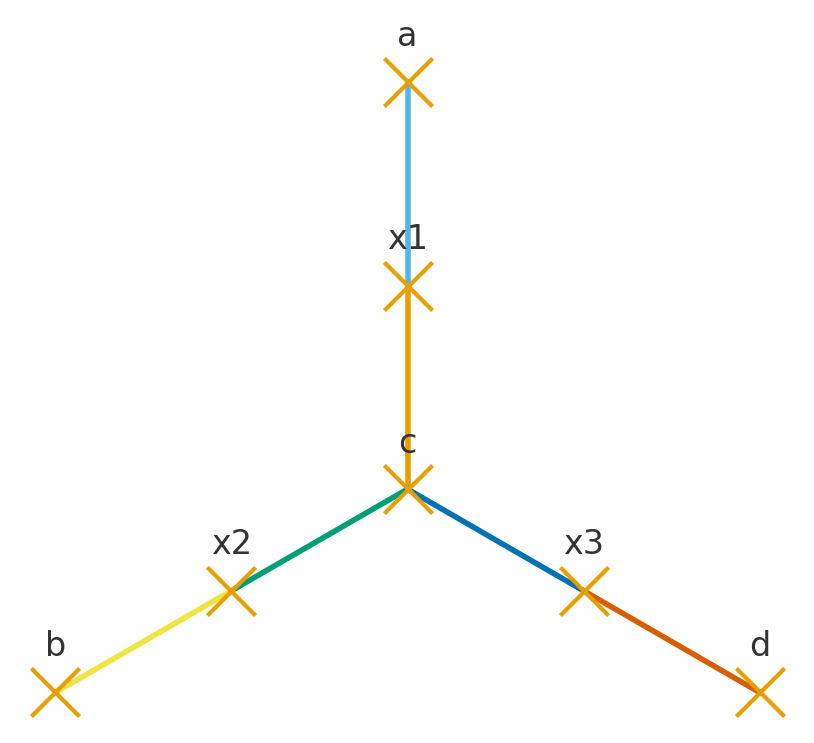

La couverture optimale pour ce graphe est `{x1; x2; x3}`, de taille 3.

Or, l'algorithme glouton revoie `{c; a; b; d}`, de taille 4.

L'algorithme glouton n'est donc pas optimal.

Nous avons donc `GLOUTON >= 4/3 * OPT`, 

`GLOUTON` n'est donc pas r-approché, `pour tout r < 4/3.`

 2. Coder les deux methodes precedentes. Les comparer (en fonction de n et p) du point de vue (1)
 de leur temps de calcul (2) de la qualite des solutions retournees.

In [76]:
def algo_couplage(G):
    C = set()
    for edge in G.edges():
        if edge[0] not in C and edge[1] not in C:
            C.add(edge[0])
            C.add(edge[1])
    return C

def algo_glouton(G):
    C = set()
    H = G.copy()
    while H.number_of_edges() > 0:
        v = max_degree_vertex(H)
        C.add(v)
        H.remove_node(v)
    return C

In [77]:
from math import sqrt

def makeTestGraphBySize(m: int, n: int, p: float, increment: int) -> List[Any]:
    """
    Make a list of graphs with probability of p and size from m to n with increment(for the size).
    Can probably used to make a graph for statistics.
    """
    grahps = []
    for i in range(m, n + 1, increment):
        grahps.append(random_graph(i, p))
    return grahps

def makeStressTestGraphBySize(m: int, n: int, increment: int) -> List[List[List[Any]]]:
    """
    Make a list of graphs with probability of 0.2, 0.5 and 0.8 and size from m to n with increment(for the size).
    Can probably used to make a graph for statistics.
    """
    graphs = [[], [], []]  # Easy, Medium, Hard
    index = 0
    for i in range(2, 9, 3):
        graphs[index].append(makeTestGraphBySize(m, n, i * 0.1, increment))
        index += 1
    
    return graphs

def testSection(algo: Callable[[Any], Any], graphs: List[Any]) -> List[Tuple[int, int, float, Any]]:
    """
    Tests the graphs with the given algorithm. returns the results including:
    [node number, edge number, time it took to execute, the result]
    """
    results = []
    print(f"Starting the test for algorithm {algo.__name__}...")
    for G in graphs:
        print(f"Testing graph with {len(G.nodes())} nodes and {len(G.edges())} edges...")
        t = get_time()
        res = algo(G)
        f = get_calctime(t)
        results.append((len(G.nodes()), len(G.edges()), f, res))
        print(f"Finished in {f} seconds.")
    return results

def stressTest(algos: List[Optional[Callable[[Any], Any]]], m: int = 5, n: int = 20, increment: int = 5) -> List[List[Any]]:
    """
    For each algorithm in `algos`, this function generates sets of random graphs
    across three fixed edge-probability levels: Easy (p=0.2), Medium (p=0.5),
    and Hard (p=0.8). For each difficulty, graphs of sizes from `m` to `n`
    (inclusive) are created using the given `increment`, and the algorithm is
    executed and timed on each graph.

    Parameters
    - algos (list[callable]): List of algorithm callables that accept a single
    graph parameter and return a result. Each callable should have a
    `__name__` attribute for logging. Elements equal to None are skipped.
    - m (int): Minimum number of nodes for generated graphs (default 5).
    - n (int): Maximum number of nodes for generated graphs (default 20).
    - increment (int): Step size between successive graph sizes (default 5).

    Side effects
    - Prints progress and timing information to stdout.
    - Uses `makeStressTestGraphBySize` to generate graphs and `testSection`
    (which uses `get_time()` / `get_calctime()`) to time executions.

    Returns
    - list: One entry per algorithm. Each algorithm entry is a list:
        [algo_name: str, easy_results: list, medium_results: list, hard_results: list]
    where each difficulty-results list contains tuples:
        (num_nodes: int, num_edges: int, elapsed_seconds: float, result: Any)

    Example
    [
    ["algo_glouton",
        [(5, 6, 0.00123, res_obj), (10, 18, 0.00234, res_obj), ...],
        [...],  # Medium
        [...]   # Hard
    ],
    ...
    ]
    """
    graphs = makeStressTestGraphBySize(m, n, increment)
    
    sections = [("Easy", 0.2), ("Medium", 0.5), ("Hard", 0.8)]
    # For algos. Each list inside will have 3 lists for each section
    results = [[f"{x.__name__}"] for x in algos]
    print(f"Each section have graphs having size ranging from {m} to {n}, with the size increment of {increment}, which makes {(n - m) // increment} graphs...")
    for algonum, algo in enumerate(algos):
        print(f"\n\n\n================ Testing sections with the algo {algo.__name__} ================")
        if algo is None:
            continue
        for i in range(3):
            print(f"\n--- Testing {sections[i][0]} section with p={sections[i][1]} ---")
            for G in graphs[i]:
                results[algonum].append(testSection(algo, G))
    return results


def nFixedTest(algos: List[Optional[Callable[[Any], Any]]], n: int = 20) -> None:
    """
    Tests for variant p.
    Applies the algos on those graphs, 10 for each class.
    """
    
    graphs = []
    index = 0
    for p in range(10):
        graphs.append([])
        for _ in range(10): #  par class
            graphs[index].append(random_graph(n, p * 0.1))
        index += 1

    """
    index = 0
    for graph in graphs:
        index += 1
        saveGraphToFile(graph[0], f"nFixedTest_{str(index).zfill(3)}_{len(graph[0].nodes())}_{len(graph[0].edges())}.txt")
    """
    
    results = [[f"{x.__name__}"] for x in algos]
    print(f"Each section have graphs having size {n}, with p ranging from 0.1 to 0.9, on 10 classes with 10 graphs each...")
    for algonum, algo in enumerate(algos):
        print(f"\n\n\n================ Testing sections with the algo {algo.__name__} ================")
        if algo is None:
            continue
        for G in graphs:
            results[algonum].append(testSection(algo, G))
    
    return results

def pFixedTest(algos: List[Optional[Callable[[Any], Any]]], n: int = 20, p: Optional[float] = None) -> None:
    """
    Tests for Nmax/10 etc. for given p.
    Applies the algos on those graphs, 10 for each class.
    """
    if p == None:
        p = 1/sqrt(n)
    m = n//10
    graphs = []
    index = 0
    for i in range(m, n + 1, m):
        graphs.append([])
        for _ in range(10): #  par class
            graphs[index].append(random_graph(i, p))
        index += 1
    
    """
    index = 0
    for graph in graphs:
        index += 1
        saveGraphToFile(graph[0], f"pFixedTest_{str(index).zfill(3)}_{len(graph[0].nodes())}_{len(graph[0].edges())}.txt")
    """
    
    results = [[f"{x.__name__}"] for x in algos]
    print(f"Each section have graphs having size ranging from {m} to {n}, with the size increment of {m}, on 10 classes with 10 graphs each...")
    for algonum, algo in enumerate(algos):
        print(f"\n\n\n================ Testing sections with the algo {algo.__name__} ================")
        if algo is None:
            continue
        for G in graphs:
            results[algonum].append(testSection(algo, G))
    
    return results
    
def FixedNTestMoyenne(results):
    # Tests faites, mtn il faut avoir les moyennes
    
    res = []
        
    for i, algo in enumerate(results):
        # start each algorithm entry with its name
        res.append([algo[0]])
        # iterate over probability-class results (skip the name at index 0)
        for j, class_results in enumerate(algo[1:]):
            if not class_results:
                # if no data for this class, append zero average
                res[i].append([j * 0.1, 0.0])
                continue
            partie_list = [resultat[2] for resultat in class_results]
            pm = sum(partie_list) / len(partie_list)
            # j corresponds to the class index (0 -> p=0.0, 1 -> p=0.1, ...)
            res[i].append([j * 0.1, pm])
                
            
    return res

def FixedPTestMoyenne(results):
    # Tests faites, mtn il faut avoir les moyennes
    
    res = []
        
    for i, algo in enumerate(results):
        for algores in algo:
            if isinstance(algores, str):
                res.append([algores])
                continue
            partie_list= [resultat[2] for resultat in algores]
            pm = sum(partie_list) / len(partie_list)
            res[i].append([algores[0][0], pm])
                
            
    return res

            
def printResultsByAlgoAndLevel(results: List[List[Any]]) -> None:
    for result in results:
        print(f"\n\nAlgorithm: {result[0]}")
        for l, level in enumerate(["easy", "medium", "hard"]):
            print(f"Level {level}")
            for res in result[l + 1]:
                print(f"Nodes: {res[0]}, Edges: {res[1]}, Time: {res[2]}, Result size: {len(res[3])}")

def testLevels(algos: List[Callable[[Any], Any]]) -> None:
    """
    Applies the stressTest to the given algos, 
    then prints them using printResultsByAlgoAndLevel.
    """
    results_leveled = stressTest(algos)
    for result in results_leveled:
        for res in result:
            print(res)
    printResultsByAlgoAndLevel(results_leveled)
    #printResultsByTest(results_leveled)

def testFixedP(algos: List[Callable[[Any], Any]]) -> None:
    results = pFixedTest(algos, 14)
    for result in results:
        for res in result:
            print(res)
    moyennes = FixedPTestMoyenne(results)
    print("Printing moyennes")
    for moyenne in moyennes:
        print(moyenne)
    
    # show plot
    for moyenne in moyennes:
        makePlotForMoyennes(moyenne)

def testFixedN(algos: List[Callable[[Any], Any]]) -> None:
    results = nFixedTest(algos, 14)
    for result in results:
        for res in result:
            print(res)
    moyennes = FixedNTestMoyenne(results)
    print("Printing moyennes")
    for moyenne in moyennes:
        print(moyenne)
    
    # show plot
    for moyenne in moyennes:
        makePlotForMoyennesNFixed(moyenne)

Each section have graphs having size ranging from 1 to 14, with the size increment of 1, on 10 classes with 10 graphs each...



================ Testing sections with the algo algo_glouton ================
Starting the test for algorithm algo_glouton...
Testing graph with 1 nodes and 0 edges...
Finished in 0.0 seconds.
Testing graph with 1 nodes and 0 edges...
Finished in 0.0 seconds.
Testing graph with 1 nodes and 0 edges...
Finished in 0.0 seconds.
Testing graph with 1 nodes and 0 edges...
Finished in 0.000997304916381836 seconds.
Testing graph with 1 nodes and 0 edges...
Finished in 0.0 seconds.
Testing graph with 1 nodes and 0 edges...
Finished in 0.0 seconds.
Testing graph with 1 nodes and 0 edges...
Finished in 0.0 seconds.
Testing graph with 1 nodes and 0 edges...
Finished in 0.0 seconds.
Testing graph with 1 nodes and 0 edges...
Finished in 0.0 seconds.
Testing graph with 1 nodes and 0 edges...
Finished in 0.0 seconds.
Starting the test for algorithm algo_glouton...
Testing gr

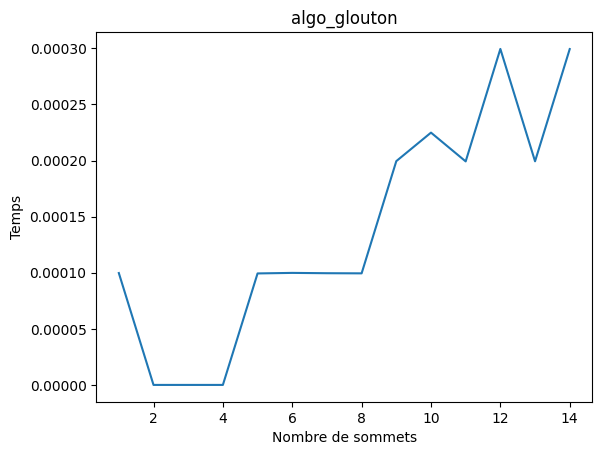

algo_couplage
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


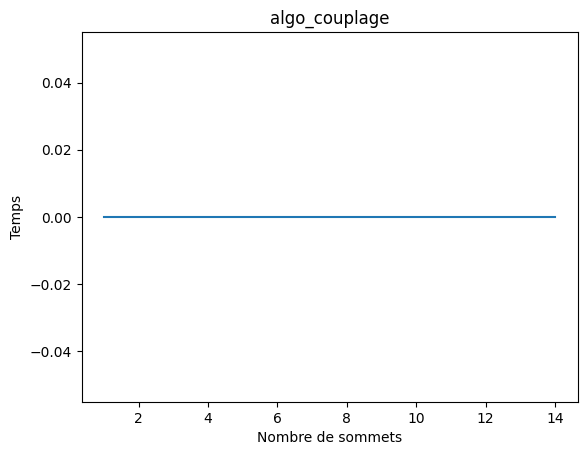

Each section have graphs having size ranging from 10 to 1000, with the size increment of 100, which makes 9 graphs...



================ Testing sections with the algo algo_glouton ================

--- Testing Easy section with p=0.2 ---
Starting the test for algorithm algo_glouton...
Testing graph with 10 nodes and 11 edges...
Finished in 0.0 seconds.
Testing graph with 110 nodes and 1226 edges...
Finished in 0.0 seconds.
Testing graph with 210 nodes and 4374 edges...
Finished in 0.029746294021606445 seconds.
Testing graph with 310 nodes and 9521 edges...
Finished in 0.05636405944824219 seconds.
Testing graph with 410 nodes and 16757 edges...
Finished in 0.09864497184753418 seconds.
Testing graph with 510 nodes and 25874 edges...
Finished in 0.12646269798278809 seconds.
Testing graph with 610 nodes and 37067 edges...
Finished in 0.21844911575317383 seconds.
Testing graph with 710 nodes and 50031 edges...
Finished in 0.30272769927978516 seconds.
Testing graph with 810 nodes and 65868

[['algo_glouton',
  [(10, 11, 0.0, {0, 1, 3, 4, 6}),
   (110,
    1226,
    0.0,
    {0,
     2,
     3,
     4,
     5,
     6,
     7,
     8,
     9,
     10,
     11,
     12,
     13,
     14,
     16,
     17,
     18,
     19,
     20,
     21,
     23,
     24,
     25,
     26,
     27,
     28,
     29,
     30,
     31,
     33,
     34,
     36,
     37,
     38,
     39,
     40,
     41,
     43,
     44,
     45,
     47,
     48,
     49,
     50,
     51,
     52,
     53,
     54,
     55,
     57,
     58,
     59,
     61,
     63,
     64,
     65,
     66,
     67,
     69,
     70,
     71,
     72,
     74,
     75,
     76,
     77,
     78,
     79,
     80,
     81,
     82,
     84,
     85,
     86,
     87,
     88,
     89,
     90,
     91,
     92,
     93,
     94,
     95,
     97,
     98,
     99,
     100,
     101,
     102,
     103,
     107,
     108,
     109}),
   (210,
    4374,
    0.029746294021606445,
    {0,
     1,
     2,
     3,
     

In [81]:
algos = [algo_glouton, algo_couplage]
#testLevels(algos)
testFixedP(algos)
stressTest(algos, m=10, n=1000, increment=100)
#TODO: plot results

 3. (Facultatif) Montrer que lalgorithme glouton precedent nest pas r-approche, quel que soit r

 Note sur les tests : Lorsque vous ferez des tests pour mesurer par exemple le temps de calcul sur
 des instances aleatoires, il vous est suggere de :
 mesurer la taille Nmax jusqua laquelle lalgorithme tourne rapidement, disons de lordre de
 quelques secondes.
 pour chaque taille d instances n 
Nmax 102Nmax 103Nmax 10
 Nmax :genererquelques
 dizaines dinstances de taille n, mesurer le temps de calcul moyen tn sur ces instances. Tracer la
 courbe tn en fonction de n sur la base de ces 10 points. On pourra penser a utiliser des echelles
 logarithmiques si besoin.
 NB:avant de faire des tests sur des instances generees, veri ez toujours que votre code fonctionne
 sur quelques exemples simples

 #### 4 Separation et evaluation
 4.1 Branchement
 Le butdecette section est de faire un premier algorithme de branchement simple. Nous lameliorerons
 dans les sections suivantes. Le branchement considere ici est le suivant : prendre une arete e = uv ,
 et considerer deux cas : soit u est dans la couverture, soit v est dans la couverture.
 Ainsi, partant dun graphe initial G et dun ensemble de sommets C vide representant la solution,
 la premiere branche consiste a mettre u dans C et a raisonner sur le graphe ou lon a supprime u (les
 aretes incidentes a u sont couvertes); symetriquement, la deuxieme consiste a mettre v dans C et a
 raisonner sur le graphe ou lon a supprime v.
 1. Coder cette methode. Vous utiliserez une pile pour gerer les n uds de larbre. Votre methode de
vra renvoyer la meilleure solution. Veri er la validite de votre methode sur des exemples
 simples (veri er que lensemble des noeuds visites est bien correct).

In [79]:
def branching(G):
    C = [] # le resultat
    pile = [(-1, G.copy(), [])] # le pile
    if len(G.edges()) == 0:
        return []
    while pile != []:
        courant = pile.pop()
        (_, Hc, solc) = courant
        if len(Hc.edges()) == 0:
            if C == []:
                C = solc.copy()
            else:
                if len(C) > len(solc):
                    C = solc.copy()
        else:
            arete = list(Hc.edges())[0]
            u, v = arete
            pile.append((u, remove_node_copy(Hc, u), solc + [u]))
            pile.append((v, remove_node_copy(Hc, v), solc + [v]))
                
    return C

 2. Tester cette methode, en evaluant son temps de calcul en fonction de n. Vous pourrez faire varier
 la probabilite p de presence des aretes. Commentez.
 NB1 : il vous est demande de faire des tests sur les temps de calcul. Il est egalement interessant
 de tester le nombre de n uds generes par les di erentes methodes. Cela est facultatif.
 NB2 : dans les tests numeriques, il est interessant de regarder linuence de p egalement (en testant
 plusieurs valeurs par exemple). On pourra aussi tester avec des valeurs comme p = 1 n pour avoir
 des graphes moins denses

Each section have graphs having size ranging from 5 to 20, with the size increment of 5, which makes 3 graphs...



================ Testing sections with the algo branching ================

--- Testing Easy section with p=0.2 ---
Starting the test for algorithm branching...
Testing graph with 5 nodes and 1 edges...
Finished in 0.0 seconds.
Testing graph with 10 nodes and 19 edges...
Finished in 0.004986286163330078 seconds.
Testing graph with 15 nodes and 17 edges...
Finished in 0.045892953872680664 seconds.
Testing graph with 20 nodes and 37 edges...
Finished in 0.877112865447998 seconds.

--- Testing Medium section with p=0.5 ---
Starting the test for algorithm branching...
Testing graph with 5 nodes and 5 edges...
Finished in 0.0 seconds.
Testing graph with 10 nodes and 28 edges...
Finished in 0.015623331069946289 seconds.
Testing graph with 15 nodes and 58 edges...
Finished in 0.570244550704956 seconds.
Testing graph with 20 nodes and 109 edges...
Finished in 14.75769329071045 se

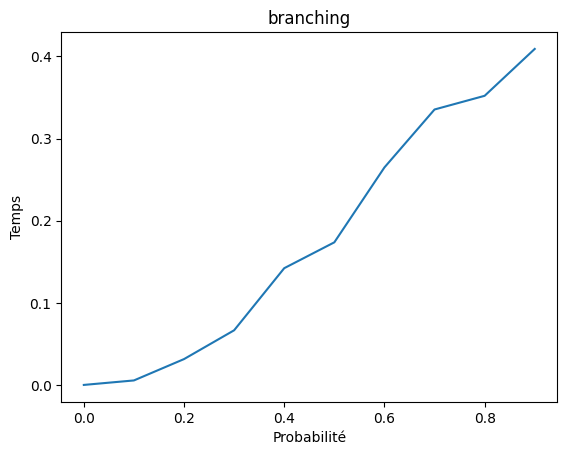

In [80]:
algos = [branching]
#testLevels(algos)
stressTest(algos)
testFixedP(algos)

#### 4.2 Ajout de bornes

Soit $G$ un graphe, $M$ un couplage de $G$ et $C$ une couverture de $G$. Alors, avec :
- $b_{1} = \left\lfloor \dfrac{m}{\Delta} \right\rfloor$ (où $\Delta$ est le degré maximum des sommets du graphe),
- $b_{2} = |M|$,
- $b_{3} = \dfrac{2n - 1 - \sqrt{(2n - 1)^{2} - 8m}}{2}$,

on a : $|C| \ge \max\{b_{1},\, b_{2},\, b_{3}\}$.

1. Montrer la validité de chacune des bornes $b_{1}$, $b_{2}$ et $b_{3}$.  
   Pour $b_{3}$, on pourra s'interroger sur le nombre maximal d'arêtes d'un graphe dont $C$ est une couverture.



Pour b₁ : $|C|\ \ge\ \left\lceil \dfrac{m}{\Delta}\right\rceil$

Chaque sommet couvre au plus $\Delta$ arêtes (définition de $\Delta$).
Pour couvrir toutes les $m$ arêtes, il faut donc au moins $m/\Delta$ sommets.
Comme $|C|$ est entier : $|C|\ \ge\ \left\lceil \tfrac{m}{\Delta}\right\rceil.$


Pour b₂ : $|C|\ \ge\ |M|$ pour tout couplage $M$

Dans un couplage $M$, les arêtes sont disjointes deux à deux.
Un même sommet de $C$ ne peut donc couvrir qu’une arête de $M$. Pour couvrir les $|M|$ arêtes de $M$, il faut au moins $|M|$ sommets : $|C|\ \ge\ |M|$.
La meilleure version est $|C|\ge \nu(G)$, où $\nu(G)$ est la taille d’un couplage maximum.

Pour b₃ : $|C|\ \ge\ \dfrac{2n-1-\sqrt{(2n-1)^2-8m}}{2}$

Soit $I=V\setminus C$ (indépendant : aucune arête à l’intérieur).
Les seules arêtes autorisées sont :
- à l’intérieur de $C$ : au plus $\binom{k}{2}$ ;
- entre $C$ et $I$ : au plus $k(n-k)$ ;
- (aucune dans $I$).

Donc, pour tout graphe dont $C$ est une couverture de taille $k$, on a
$m\ \le\ k(n-k)\ +\ \binom{k}{2}\ =\ kn-\dfrac{k^2+k}{2}$.
Donnant l'inégalité :
$k^2 + (1-2n)k + 2m \ \le\ 0$.
Les racines sont
$k_{\pm}=\dfrac{(2n-1)\ \pm\ \sqrt{(2n-1)^2-8m}}{2}$.
Comme le coefficient de $k^2$ est positif, l’inégalité $\le0$ est vraie pour
$k\in[k_{-},\,k_{+}]$. Or $k=|C|$ doit appartenir à cet intervalle, donc en particulier
$|C|\ \ge\ k_{-}\ =\ \dfrac{2n-1-\sqrt{(2n-1)^2-8m}}{2}$.
Pour une borne entière :
$|C|\ \ge\ \left\lceil \dfrac{2n-1-\sqrt{(2n-1)^2-8m}}{2}\right\rceil$.


Chaqune des bornes est donc valide :
$|C|\ \ge\ \max\!\left\{
\left\lceil \tfrac{m}{\Delta}\right\rceil,\ \ |M|,\ \
\dfrac{2n-1-\sqrt{(2n-1)^2-8m}}{2}
\right\}$,


 2. Inserer dans l algorithme precedent (1) le calcul (en chaque n ud) dune solution realisable
 obtenue avec lalgorithme de couplage (2) le calcul dune borne inferieure basee sur la relation
 precedente. Tester cette nouvelle methode, et commenter.

 3. (Facultatif) Evaluer linteret dutiliser aussi lalgorithme glouton pour generer des solutions
 realisables. Evaluer le cacite des methodes si lon nutilise que les bornes inferieures, ou que le
 calcul de solution realisable (avec une borne inferieure triviale).

 #### 4.3 Amelioration du branchement
 Lorsque lon branche sur une arete e = uv , dans la deuxieme branche ou lon prend le sommet
 v dans la couverture, on peut supposer que lon ne prend pas le sommet u (le cas ou on le prend etant
 traite dans la premiere branche. Dans la 2eme branche, ne prenant pas u dans la couverture on doit
 alors prendre tous les voisins de u (et on peut les supprimer du graphe donc).
 1. Modi er la methode precedente en utilisant ce branchement ameliore. Tester la nouvelle methode,
 et commenter les resultats obtenus.

2. An deliminer un maximum de sommets dans la deuxieme branche, il semble interessant de
 choisir le branchement de maniere a ce que le sommet u soit de degre maximum dans le graphe
 restant. Tester la nouvelle methode, et commenter les resultats obtenus.

 3. (Facultatif) Dans un graphe G, si un sommet u est de degre 1, expliquer pourquoi il existe
 toujours une couverture optimale qui ne contient pas u. Inserer alors ce test permettant de
 supprimer un sommet sans brancher. Evaluer experimentalement linteret dajouter ce test.

#### 4.4 Qualite des algorithmes approches
 1. Evaluer experimentalement (en fonction de n) le rapport dapproximation des algorithmes de cou
plage et glouton. Donneregalement le pire rapport dapproximation obtenu lors des experimentations,
 pour chacun des deux algorithmes.

 2. (Facultatif) Proposer une ou plusieurs autres heuristiques, et les evaluer experimentalement.